In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

DATASET_DIR = r"C:\Users\91997\Parkinson-s-Disease-Tremor-Dataset\PD-BioStamp"

x_files = sorted([f for f in os.listdir(DATASET_DIR) if f.endswith("-X.npy")])
y_files = sorted([f for f in os.listdir(DATASET_DIR) if f.endswith("-Y.npy")])

print(f"X files found: {len(x_files)}")
print(f"Y files found: {len(y_files)}")
print(f"First few: {x_files[:5]}")


X files found: 399
Y files found: 399
First few: ['1-X.npy', '10-X.npy', '100-X.npy', '101-X.npy', '102-X.npy']


In [2]:
import os
print(os.getcwd())
print(os.listdir("."))

C:\Users\91997\Desktop\Parkinson-s-Disease-Tremor-Dataset
['.ipynb_checkpoints', '01_data_exploration.ipynb', '02_feature_extraction.ipynb', '03_classification_loso.ipynb', '04_shap_analysis.ipynb', 'data', 'figures', 'README.md', 'requirements.txt']


In [4]:
X_list = []
Y_list = []
subject_list = []

skipped = []

for xf in x_files:
    subject_id = xf.replace("-X.npy", "")
    yf = xf.replace("-X.npy", "-Y.npy")

    if yf not in y_files:
        skipped.append(xf)
        continue

    x_data = np.load(os.path.join(DATASET_DIR, xf))
    y_data = np.load(os.path.join(DATASET_DIR, yf))

    if x_data.ndim == 2:
        x_data = x_data[:, :, np.newaxis]

    if len(x_data) != len(y_data):
        skipped.append(xf)
        continue

    X_list.append(x_data)
    Y_list.append(y_data)
    subject_list.append(np.full(len(y_data), subject_id))

X = np.concatenate(X_list, axis=0)
Y = np.concatenate(Y_list, axis=0)
subject_ids = np.concatenate(subject_list, axis=0)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"subject_ids shape: {subject_ids.shape}")
print(f"Subjects loaded: {len(np.unique(subject_ids))}")
if skipped:
    print(f"Skipped: {skipped}")


X shape: (1947, 128, 3)
Y shape: (1947,)
subject_ids shape: (1947,)
Subjects loaded: 399


In [5]:
sample_x = np.load(os.path.join(DATASET_DIR, x_files[0]))
print(f"Single file shape: {sample_x.shape}")
print(f"X dtype: {X.dtype}, Y dtype: {Y.dtype}")
print(f"Y unique values: {np.unique(Y)}")
print(f"Y value counts: {dict(zip(*np.unique(Y, return_counts=True)))}")


Single file shape: (2, 128, 3)
X dtype: float32, Y dtype: int64
Y unique values: [0 1 2 3]
Y value counts: {np.int64(0): np.int64(1791), np.int64(1): np.int64(47), np.int64(2): np.int64(87), np.int64(3): np.int64(22)}


In [6]:
if X.ndim == 2:
    print(f"X is 2D: {X.shape} — single axis accelerometer")
    X = X[:, :, np.newaxis]
    print(f"Reshaped to: {X.shape}")
elif X.ndim == 3:
    print(f"X is 3D: {X.shape} — multi-axis accelerometer")

n_axes = X.shape[2]
window_len = X.shape[1]
fs = 50
print(f"Window length: {window_len} samples = {window_len/fs:.2f} seconds at {fs} Hz")
print(f"Number of axes: {n_axes}")


X is 3D: (1947, 128, 3) — multi-axis accelerometer
Window length: 128 samples = 2.56 seconds at 50 Hz
Number of axes: 3


In [7]:
label_names = {0: "No Tremor", 1: "Mild", 2: "Moderate", 3: "Severe"}
counts = dict(zip(*np.unique(Y, return_counts=True)))
total = len(Y)

print("Class Distribution")
print("=" * 45)
for k in sorted(counts.keys()):
    v = counts[k]
    name = label_names.get(int(k), str(k))
    print(f"  Label {k} ({name}): {v:>6} samples ({100*v/total:.1f}%)")
print(f"  Total: {total}")


Class Distribution
  Label 0 (No Tremor):   1791 samples (92.0%)
  Label 1 (Mild):     47 samples (2.4%)
  Label 2 (Moderate):     87 samples (4.5%)
  Label 3 (Severe):     22 samples (1.1%)
  Total: 1947


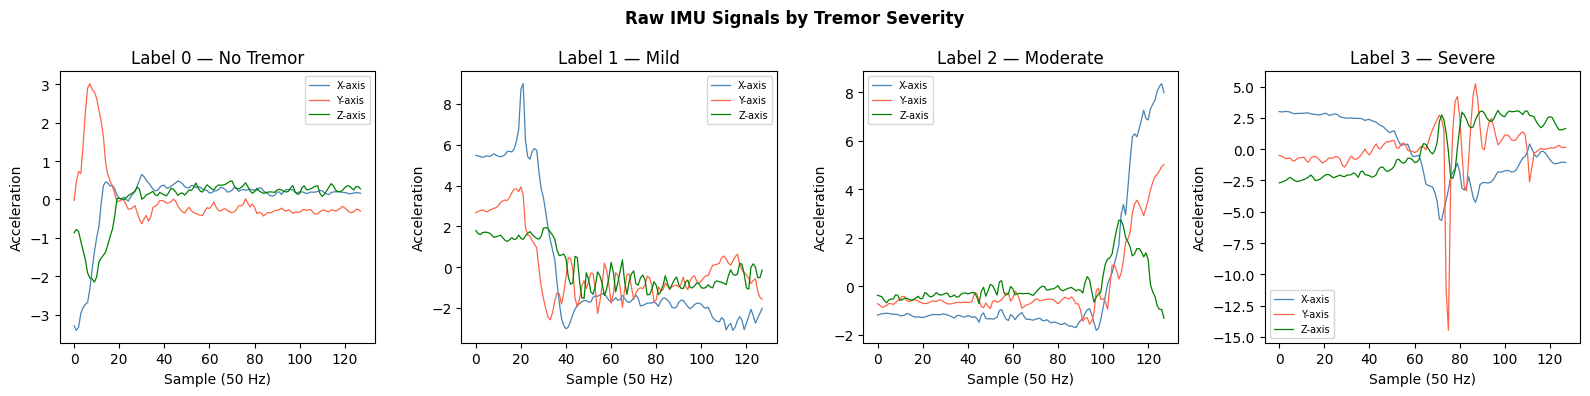

In [8]:
os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)

fig, axes = plt.subplots(1, len(counts), figsize=(4*len(counts), 4))
if len(counts) == 1:
    axes = [axes]

n_axes_plot = min(X.shape[2], 3)
axis_labels = ["X", "Y", "Z"]
colors = ["steelblue", "tomato", "green"]

for plot_i, cls in enumerate(sorted(counts.keys())):
    idx = np.where(Y == cls)[0]
    sample = X[idx[0]]
    ax = axes[plot_i]
    for a in range(n_axes_plot):
        ax.plot(sample[:, a], label=f"{axis_labels[a]}-axis",
                linewidth=0.9, color=colors[a])
    ax.set_title(f"Label {cls} — {label_names.get(int(cls), str(cls))}")
    ax.set_xlabel(f"Sample ({fs} Hz)")
    ax.set_ylabel("Acceleration")
    ax.legend(fontsize=7)

plt.suptitle("Raw IMU Signals by Tremor Severity", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/01_raw_signals_by_class.png", dpi=150, bbox_inches="tight")
plt.show()


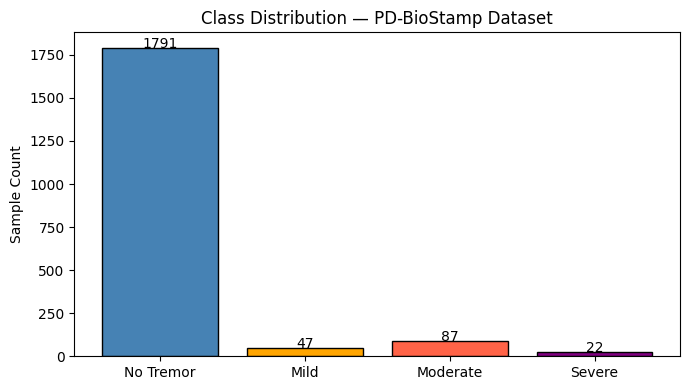

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
labels_plot = [label_names.get(int(k), str(k)) for k in sorted(counts.keys())]
values_plot = [counts[k] for k in sorted(counts.keys())]
bar_colors = ["steelblue", "orange", "tomato", "purple"][:len(counts)]

bars = ax.bar(labels_plot, values_plot, color=bar_colors, edgecolor="black")
ax.set_ylabel("Sample Count")
ax.set_title("Class Distribution — PD-BioStamp Dataset")
for bar, v in zip(bars, values_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("figures/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
np.save("data/X.npy", X)
np.save("data/Y.npy", Y)
np.save("data/subject_ids.npy", subject_ids)

print(f"Saved:")
print(f"  data/X.npy          {X.shape}")
print(f"  data/Y.npy          {Y.shape}")
print(f"  data/subject_ids.npy {subject_ids.shape}")
print(f"  Subjects: {len(np.unique(subject_ids))}")
print(f"  Classes:  {sorted(np.unique(Y).tolist())}")


Saved:
  data/X.npy          (1947, 128, 3)
  data/Y.npy          (1947,)
  data/subject_ids.npy (1947,)
  Subjects: 399
  Classes:  [0, 1, 2, 3]
